### Import Libraries

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import KNNImputer
%pip install hyperopt
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.pyll.base import scope
from sklearn.metrics import f1_score




Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Load Data

In [15]:
file_path = '../data/processed/Austin_Weather_Processed.csv'
data = pd.read_csv(file_path)

# Convert boolean column to numeric
data['isHeatWave'] = data['isHeatWave'].astype(int)

# Optional: convert Date to datetime
data['Date'] = pd.to_datetime(data['Date'])

features = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF',
            'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles',
            'PrecipitationSumInches', 'Year', 'DayOfYear', 'WeekOfYear']


X = data[features]
y = data['isHeatWave_NextDay']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Training Set Shapes (80%) ---")
print(f"X_train:           {X_train.shape}")
print(f"y_train:  {y_train.shape}")

print("\n--- Testing Set Shapes (20%) ---")
print(f"X_test:            {X_test.shape}")
print(f"y_test:   {y_test.shape}")

--- Training Set Shapes (80%) ---
X_train:           (8283, 11)
y_train:  (8283,)

--- Testing Set Shapes (20%) ---
X_test:            (2071, 11)
y_test:   (2071,)


### Proccess Data

In [17]:
# Replace invalid entries and convert to numeric
invalid_strings = ['-', '', '#VALUE!']
for col in X_train.columns:

    # Replace and coerce for X_train
    X_train[col] = X_train[col].replace(invalid_strings, np.nan)
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

    # Replace and coerce for X_test
    X_test[col] = X_test[col].replace(invalid_strings, np.nan)
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

imputer = KNNImputer(n_neighbors=3)

X_train_imputed_array = imputer.fit_transform(X_train)

X_test_imputed_array = imputer.transform(X_test)


# Convert back to DataFrame to preserve column names
X_train_imputed = pd.DataFrame(X_train_imputed_array, columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed_array, columns=X_test.columns, index=X_test.index)


### Bayesian Optimization

In [18]:
# Use scope to ensure some values are treated as integers
search_space = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 50, 200, 25)),
    'max_depth': scope.int(hp.quniform('max_depth', 5, 20, 1)),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None, 0.5]),
    'criterion': hp.choice('criterion', ['gini', 'entropy']),
    'min_samples_split': scope.int(hp.quniform('min_samples_split', 2, 10, 1)),
    'class_weight': hp.choice('class_weight', ['balanced', 'balanced_subsample', None])
}

### Bayesian Objective Function

In [19]:
def objective_tommorow(params):
    # Initialize the model (ensure types are handled if using hp.quniform for ints)
    model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']), # Ensure integer conversion if needed
        max_depth=int(params['max_depth']),      # Ensure integer conversion if needed
        max_features=params['max_features'],
        criterion=params['criterion'],
        min_samples_split=int(params['min_samples_split']), # Ensure integer conversion if needed
        class_weight=params['class_weight'],
        random_state=42,
        n_jobs=-1
    )

   # Use 5-fold cross-validation
    try:
        score = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='f1_weighted').mean()
    except ValueError as e:
        return 1.0

    loss = -score
    return loss

### Run Optimization(Tommorow)

In [20]:
trials = Trials()
# Run the optimization for 100 evaluations
BEST_RUNS = 100
best_params = fmin(
    fn=objective_tommorow,
    space=search_space,
    algo=tpe.suggest,
    max_evals=BEST_RUNS,
    trials=trials,
    rstate=np.random.default_rng(42)
)

100%|██████████| 100/100 [00:02<00:00, 39.52trial/s, best loss: 1.0]


### Display Results

In [21]:
feature_choices = ['sqrt', 'log2', None, 0.5]
criterion_choices = ['gini', 'entropy']
class_weight_choices = ['balanced', 'balanced_subsample', None]

best_max_features = feature_choices[best_params['max_features']]
best_criterion = criterion_choices[best_params['criterion']]
best_class_weight = class_weight_choices[best_params['class_weight']]

final_params = {
    'n_estimators': int(best_params['n_estimators']),
    'max_depth': int(best_params['max_depth']),
    'max_features': best_max_features,
    'criterion': best_criterion,
    'min_samples_split': int(best_params['min_samples_split']),
    'class_weight': best_class_weight,
    'random_state': 42
}

print(f"\n✅ Bayesian Optimization Complete after {BEST_RUNS} runs.")
print("\nOptimal Hyperparameters:")
print(final_params)


✅ Bayesian Optimization Complete after 100 runs.

Optimal Hyperparameters:
{'n_estimators': 175, 'max_depth': 15, 'max_features': 'log2', 'criterion': 'entropy', 'min_samples_split': 7, 'class_weight': 'balanced_subsample', 'random_state': 42}


### Train Random Forest(Tommorow is HeatWave?)

In [22]:
# Handle missing values with KNNImputer
print("Checking for missing values...")
print(f"Missing values in X_train: {X_train.isna().sum().sum()}")
print(f"Missing values in X_test: {X_test.isna().sum().sum()}")

# Impute missing values
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame (optional, keeps column names)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test = pd.DataFrame(X_test_imputed, columns=X_test.columns)

print("Missing values after imputation:")
print(f"X_train: {X_train.isna().sum().sum()}")
print(f"X_test: {X_test.isna().sum().sum()}")

print("\n## Model: Tomorrow's Heat Wave Prediction")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Checking for missing values...
Missing values in X_train: 15
Missing values in X_test: 0
Missing values after imputation:
X_train: 0
X_test: 0

## Model: Tomorrow's Heat Wave Prediction
Accuracy: 0.9111540318686625
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1410
           1       0.86      0.86      0.86       661

    accuracy                           0.91      2071
   macro avg       0.90      0.90      0.90      2071
weighted avg       0.91      0.91      0.91      2071



### Extract Model

In [23]:
import joblib
import os

output_dir = '../models'
filename_tommorow = 'random_forest_model_predict_tommorow.joblib'

save_path_tommorow = os.path.join(output_dir, filename_tommorow)

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Directory check complete: {output_dir}")

# Save the trained model to the specified path
joblib.dump(rf, save_path_tommorow)

print(f"\n✅ Model successfully saved to: {save_path_tommorow}")

Directory check complete: ../models

✅ Model successfully saved to: ../models\random_forest_model_predict_tommorow.joblib


### Load Model

In [24]:
# Define the exact path to the saved file
output_dir = '../models'
filename = 'random_forest_model_predict_tommorow.joblib'
load_path = os.path.join(output_dir, filename)


# Load the model
try:
    loaded_rf = joblib.load(load_path)
    print(f"\n✅ Model successfully loaded from: {load_path}")
    print(f"Model type: {type(loaded_rf)}")

    y_pred = loaded_rf.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
except FileNotFoundError:
    print(f"\n❌ Error: File not found at {load_path}.")
    print("Please verify the directory and filename in your Google Drive.")


✅ Model successfully loaded from: ../models\random_forest_model_predict_tommorow.joblib
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Accuracy: 0.9111540318686625
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1410
           1       0.86      0.86      0.86       661

    accuracy                           0.91      2071
   macro avg       0.90      0.90      0.90      2071
weighted avg       0.91      0.91      0.91      2071



### Display Graphs

In [25]:
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# Define the output directory
OUTPUT_DIR = '../reports/figures/classification'

# Create the directory if it doesn't exist (to prevent errors)
os.makedirs(OUTPUT_DIR, exist_ok=True)

final_model = rf

# Generate predictions and probabilities on the test set
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1] # Probability of Class 1

### Confusion Matrix

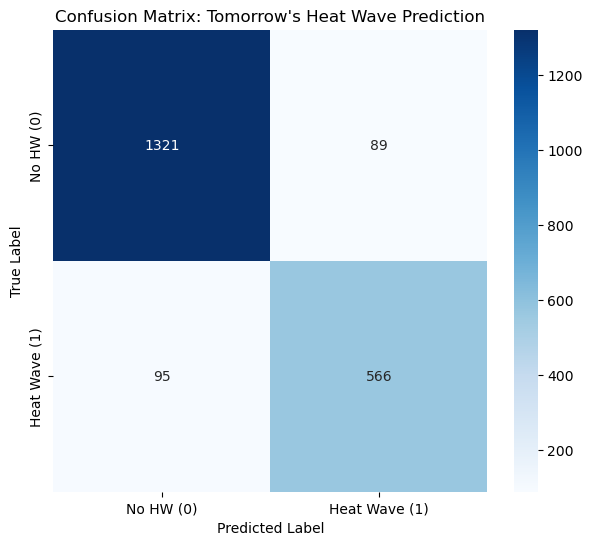

In [26]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No HW (0)', 'Heat Wave (1)'],
            yticklabels=['No HW (0)', 'Heat Wave (1)'])
plt.title('Confusion Matrix: Tomorrow\'s Heat Wave Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_confusion_matrix_tomorrow.png'))
plt.show()
plt.close() # Close plot to free memory

### ROC Curve and AUC

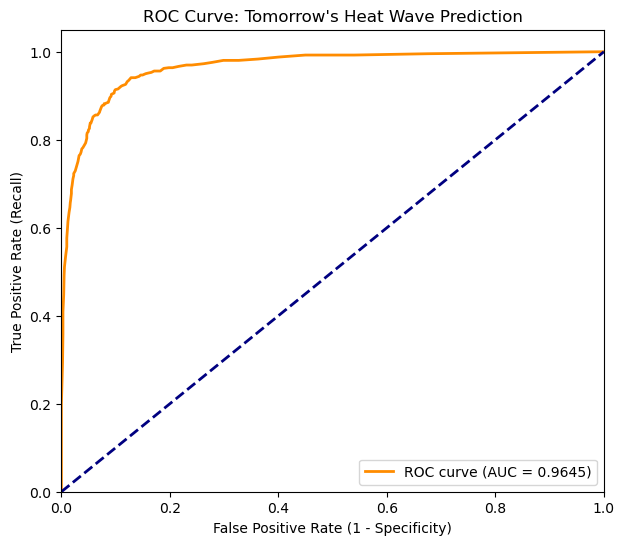

In [27]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Tomorrow\'s Heat Wave Prediction')
plt.legend(loc='lower right')
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_roc_curve_tomorrow.png'))
plt.show()

### Precision-Recall Curve

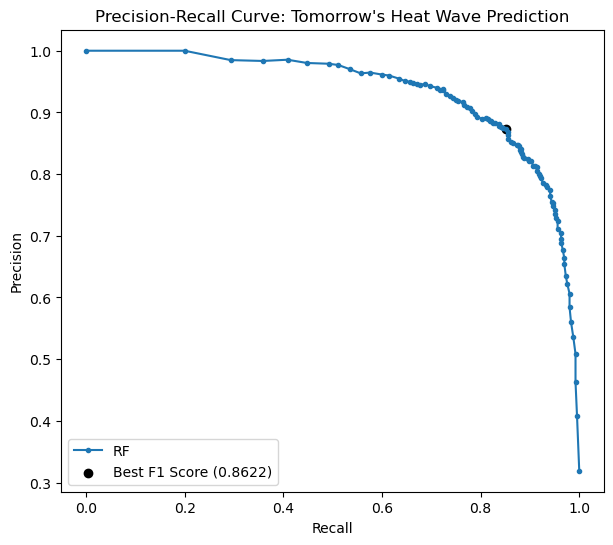

In [28]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
fscores = (2 * precision * recall) / (precision + recall)
# Find the threshold that yields the best f1 score
ix = np.nanargmax(fscores)
best_fscore = fscores[ix]

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, marker='.', label='RF')
plt.scatter(recall[ix], precision[ix], marker='o', color='black', label=f'Best F1 Score ({best_fscore:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Tomorrow\'s Heat Wave Prediction')
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_precision_recall_curve_tomorrow.png'))
plt.show()

### Feature Importance Plot

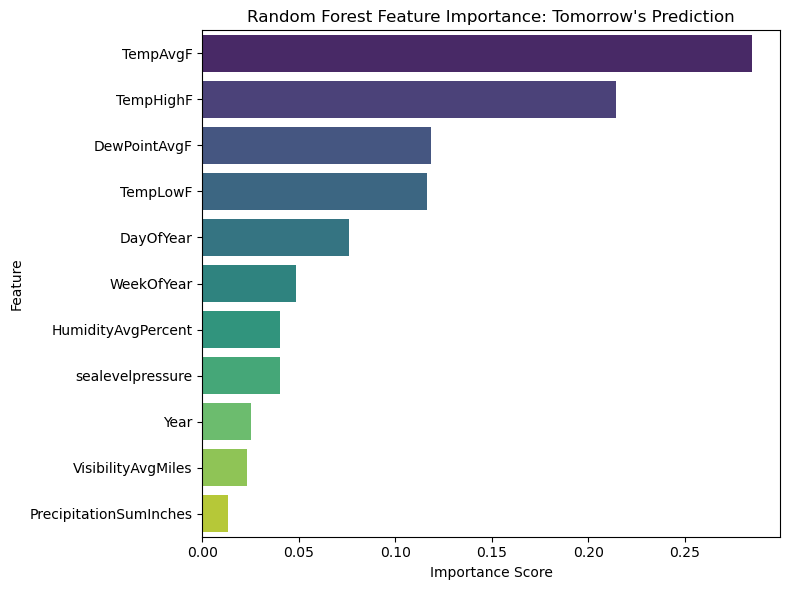

In [29]:
# Ensure the 'features' list is available in your environment
feature_importance = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")
plt.title('Random Forest Feature Importance: Tomorrow\'s Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_feature_importance_tomorrow.png'))
plt.show()

### Save Predictions

In [30]:
OUTPUT_DIR = '../reports/predictions'
FILE_NAME = 'rf_tomorrow_heatwave_predictions_report.csv'

# Generate Final Predictions and Probabilities
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1] # Probability of Heat Wave (Class 1)

# Create the Results DataFrame
results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Predicted_Probability': y_proba
})

# Add Date Index (Crucial for time series analysis)
if 'Date' in data.columns:
    # Use the index from the test features to align the dates
    test_dates = data.loc[X_test.index, 'Date']
    results_df = results_df.set_index(test_dates)
    results_df.index.name = 'Date'
else:
    # If Date wasn't used, just reset the index name
    results_df.index.name = 'Test_Sample_Index'


# save to CSV
output_path = os.path.join(OUTPUT_DIR, FILE_NAME)
results_df.to_csv(output_path, index=True)

print(f"✅ Prediction report successfully saved to: {output_path}")

✅ Prediction report successfully saved to: ../reports/predictions\rf_tomorrow_heatwave_predictions_report.csv


### Save Model Metrics

In [31]:
from sklearn.metrics import  precision_recall_fscore_support

# Define the output directory and file path
OUTPUT_DIR = '../reports/predictions'
CSV_FILE = os.path.join(OUTPUT_DIR, 'rf_tomorrow_metrics.csv')

# Ensure the directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Get predictions
y_pred = rf.predict(X_test)

#Calculate metrics
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
# Create the DataFrame
accuracy = accuracy_score(y_test, y_pred)
report_df.loc['accuracy', 'precision'] = accuracy
report_df.loc['accuracy', 'recall'] = accuracy
report_df.loc['accuracy', 'f1-score'] = accuracy

# Save to CSV
report_df.to_csv(CSV_FILE, index=True)